In [60]:
#required libraries
from Bio import Entrez
from Bio import SeqIO
from Bio.Blast import NCBIWWW, NCBIXML
from Bio.PDB import PDBParser, PDBIO, Select, Superimposer
from IPython.display import display, HTML

import pandas as pd
import requests
import io
import os
import py3Dmol
import numpy as np
import matplotlib.pyplot as plt

print("Packages loaded.")


Packages loaded.


In [ ]:
#environment setup
!pip install biopython requests pandas matplotlib py3Dmol -q
!apt-get update
!apt-get install openbabel -y
!wget https://github.com/gnina/gnina/releases/download/v1.1/gnina -O gnina
!chmod +x gnina
!./gnina --help

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://cli.github.com/packages stable InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openbabel is already the newest version (3.1.1+dfsg-6ubuntu5).
0 upgraded, 0 newly installed, 

In [ ]:
Entrez.email = "ah2502447@gmail.com"

gene_name = "PTEN"

# Human PTEN RefSeq mRNA
ncbi_mrna_id = "NM_000314.8"

print("Gene:", gene_name)
print("Accession:", ncbi_mrna_id)

Gene: PTEN
Accession: NM_000314.8


In [ ]:
#NCBI sequence retrieval
handle = Entrez.efetch(
    db="nucleotide",
    id=ncbi_mrna_id,
    rettype="gb",
    retmode="text"
)

record = SeqIO.read(handle,"genbank")

handle.close()

print("Downloaded:", record.id)
print("Length:", len(record.seq))

Downloaded: NM_000314.8
Length: 8515


In [ ]:
dna = None

for feature in record.features:

    if feature.type == "CDS":

        dna = feature.extract(record.seq)

        break

if dna is None:
    raise ValueError("CDS not found")

print("DNA Length:", len(dna))

DNA Length: 1212


In [ ]:
print("First 300 bases:\n")

print(str(dna)[:300])

First 300 bases:

ATGACAGCCATCATCAAAGAGATCGTTAGCAGAAACAAAAGGAGATATCAAGAGGATGGATTCGACTTAGACTTGACCTATATTTATCCAAACATTATTGCTATGGGATTTCCTGCAGAAAGACTTGAAGGCGTATACAGGAACAATATTGATGATGTAGTAAGGTTTTTGGATTCAAAGCATAAAAACCATTACAAGATATACAATCTTTGTGCTGAAAGACATTATGACACCGCCAAATTTAATTGCAGAGTTGCACAATATCCTTTTGAAGACCATAACCCACCACAGCTAGAACTT


In [ ]:
with open("PTEN_DNA.fasta","w") as f:

    f.write(">PTEN_DNA\n")
    f.write(str(dna))

print("DNA FASTA saved")

DNA FASTA saved


In [ ]:
#Read DNA from FASTA file
record = SeqIO.read("PTEN_DNA.fasta", "fasta")
dna = record.seq

#Transcribe DNA → mRNA
mrna = dna.transcribe()

print("mRNA generated successfully")
print("Length of mRNA:", len(mrna))

# Preview
print("\nFirst 100 bases of mRNA:\n")
print(mrna[:100])

mRNA generated successfully
Length of mRNA: 1212

First 100 bases of mRNA:

AUGACAGCCAUCAUCAAAGAGAUCGUUAGCAGAAACAAAAGGAGAUAUCAAGAGGAUGGAUUCGACUUAGACUUGACCUAUAUUUAUCCAAACAUUAUUG


In [ ]:
# Save mRNA to FASTA file

with open("PTEN_mRNA.fasta", "w") as f:
    f.write(">PTEN_mRNA\n")
    f.write(str(mrna))

print("mRNA FASTA file saved successfully")

mRNA FASTA file saved successfully


In [ ]:
#Read mRNA from FASTA file
record = SeqIO.read("PTEN_mRNA.fasta", "fasta")
mrna_seq = record.seq

print("Running BLASTN on PTEN mRNA...")

#Run BLASTN
blast_result = NCBIWWW.qblast(
    program="blastn",
    database="nt",
    sequence=str(mrna_seq),
    hitlist_size=5
)

# Save BLAST output
blast_xml = blast_result.read()

with open("PTEN_mRNA_BLAST.xml", "w") as f:
    f.write(blast_xml)

print("BLASTN completed and saved.")

Running BLASTN on PTEN mRNA...
BLASTN completed and saved.


In [ ]:
# Open saved BLAST file
with open("PTEN_mRNA_BLAST.xml") as f:
    blast_record = NCBIXML.read(f)

rows = []

# Take top 5 hits
for i, hit in enumerate(blast_record.alignments[:5]):

    hsp = hit.hsps[0]

    identity = (hsp.identities / hsp.align_length) * 100

    rows.append([
        i + 1,
        hit.title,
        hsp.align_length,
        round(identity, 2),
        hsp.expect
    ])

blast_table = pd.DataFrame(
    rows,
    columns=["Rank", "Hit", "Alignment Length", "Identity %", "E-value"]
)

blast_table

,Rank,Hit,Alignment Length,Identity %,E-value
0,1,gi|304368213|gb|HM849631.1| Homo sapiens clone...,1212,100.0,0.0
1,2,gi|628601828|tpg|BK008756.1| TPA_exp: Homo sap...,1212,100.0,0.0
2,3,gi|1520682131|ref|NM_001304717.5| Homo sapiens...,1212,100.0,0.0
3,4,gi|304368219|gb|HM849634.1| Homo sapiens clone...,1212,100.0,0.0
4,5,gi|304368211|gb|HM849630.1| Homo sapiens clone...,1212,100.0,0.0


In [ ]:
# Read mRNA sequence
record = SeqIO.read("PTEN_mRNA.fasta", "fasta")

mrna_seq = record.seq

# Translate mRNA into protein
protein = mrna_seq.translate(to_stop=True)

print("Protein Length:", len(protein))
print("\nFirst 100 amino acids:\n")
print(protein[:100])

Protein Length: 403

First 100 amino acids:

MTAIIKEIVSRNKRRYQEDGFDLDLTYIYPNIIAMGFPAERLEGVYRNNIDDVVRFLDSKHKNHYKIYNLCAERHYDTAKFNCRVAQYPFEDHNPPQLEL


In [ ]:
with open("PTEN_Protein.fasta", "w") as f:
    f.write(">PTEN_Protein\n")
    f.write(str(protein))

print("Protein FASTA saved successfully")

Protein FASTA saved successfully


In [ ]:
#Download the Official PTEN Protein

protein_id = "NP_000305.3"

handle = Entrez.efetch(
    db="protein",
    id=protein_id,
    rettype="fasta",
    retmode="text"
)

official_protein = SeqIO.read(handle, "fasta")

handle.close()

print(official_protein.description)
print("Length:", len(official_protein.seq))

NP_000305.3 phosphatidylinositol 3,4,5-trisphosphate 3-phosphatase and dual-specificity protein phosphatase PTEN isoform PTEN [Homo sapiens]
Length: 403


In [ ]:
with open("PTEN_Official_Protein.fasta", "w") as f:
    SeqIO.write(official_protein, f, "fasta")

print("Official PTEN protein saved")

Official PTEN protein saved


In [ ]:
#Compare Translated protein with Official PTEN
translated = str(protein)
official = str(official_protein.seq)

print("Translated Length:", len(translated))
print("Official Length:", len(official))

print("Sequences Match:", translated == official)

Translated Length: 403
Official Length: 403
Sequences Match: True


In [ ]:
# Read protein FASTA
record = SeqIO.read("PTEN_Protein.fasta", "fasta")
protein_seq = record.seq

print("Running BLASTP on PTEN protein...")

blast_result = NCBIWWW.qblast(
    program="blastp",
    database="nr",
    sequence=str(protein_seq),
    hitlist_size=5
)

blast_xml = blast_result.read()

with open("PTEN_Protein_BLAST.xml", "w") as f:
    f.write(blast_xml)

print("BLASTP completed and saved.")

Running BLASTP on PTEN protein...
BLASTP completed and saved.


In [ ]:
#Show Top 5 Hits as a Table
with open("PTEN_Protein_BLAST.xml") as f:
    blast_record = NCBIXML.read(f)

rows = []

for i, hit in enumerate(blast_record.alignments[:5]):

    hsp = hit.hsps[0]

    identity = (hsp.identities / hsp.align_length) * 100

    rows.append([
        i + 1,
        hit.title,
        hsp.align_length,
        round(identity, 2),
        hsp.expect
    ])

blastp_table = pd.DataFrame(
    rows,
    columns=["Rank", "Protein Hit", "Alignment Length", "Identity %", "E-value"]
)

blastp_table

,Rank,Protein Hit,Alignment Length,Identity %,E-value
0,1,gb|QID04980.1| PTENepsilon [Homo sapiens],403,100.00,0.0
1,2,"ref|NP_000305.3| phosphatidylinositol 3,4,5-tr...",403,100.00,0.0
2,3,"gb|AAX43209.1| phosphatase and tensin-like, pa...",403,99.75,0.0
3,4,"ref|XP_015354355.1| phosphatidylinositol 3,4,5...",403,99.75,0.0
4,5,"ref|XP_008268354.1| phosphatidylinositol 3,4,5...",403,100.00,0.0


In [ ]:
#Download PDB structure
pdb_id = "1D5R"

url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

response = requests.get(url)

if response.status_code == 200:
    with open("PTEN_1D5R.pdb", "w") as f:
        f.write(response.text)
    print("PDB downloaded successfully:", pdb_id)
else:
    print("Download failed")

PDB downloaded successfully: 1D5R


In [ ]:
file_path = "PTEN_1D5R.pdb"

with open(file_path) as f:
    lines = f.readlines()

info = {
    "PDB ID": None,
    "Title": None,
    "Method": None,
    "Resolution": None,

}

for line in lines:

    if line.startswith("HEADER"):
        info["PDB ID"] = line.split()[-1]

    if line.startswith("TITLE"):
        info["Title"] = line[10:].strip()

    if line.startswith("EXPDTA"):
        info["Method"] = line[10:].strip()

    if "RESOLUTION." in line:
        parts = line.split()
        info["Resolution"] = parts[-2] + " Å"



print(info)

{'PDB ID': '1D5R', 'Title': 'CRYSTAL STRUCTURE OF THE PTEN TUMOR SUPPRESSOR', 'Method': 'X-RAY DIFFRACTION', 'Resolution': '2.10 Å'}


In [ ]:
#Extract Ligands / HETATM (PTEN structure contents)
het_residues = []

with open("PTEN_1D5R.pdb", "r") as f:
    for line in f:
        if line.startswith("HETATM"):
            het_residues.append(line[17:20].strip())

import pandas as pd

het_table = pd.Series(het_residues).value_counts().reset_index()
het_table.columns = ["Residue", "Atom_count"]

het_table

,Residue,Atom_count
0,HOH,382
1,TLA,10


In [ ]:
#Clean receptor for docking

pdb_file = "PTEN_1D5R.pdb"

parser = PDBParser(QUIET=True)
structure = parser.get_structure("PTEN", pdb_file)

class ProteinSelect(Select):
    def accept_residue(self, residue):
        return residue.id[0] == " "

class WaterSelect(Select):
    def accept_residue(self, residue):
        return residue.get_resname() == "HOH"

class LigandSelect(Select):
    def accept_residue(self, residue):
        return residue.id[0] != " " and residue.get_resname() != "HOH"

io = PDBIO()
io.set_structure(structure)

io.save("PTEN_cleanprotein.pdb", ProteinSelect())
io.save("PTEN_waters.pdb", WaterSelect())
io.save("PTEN_ligands.pdb", LigandSelect())

print("Files saved successfully:")
print("PTEN_cleanprotein.pdb")
print("PTEN_waters.pdb")
print("PTEN_ligands.pdb")

Files saved successfully:
PTEN_cleanprotein.pdb
PTEN_waters.pdb
PTEN_ligands.pdb


In [ ]:
#Download AlphaFold structure
url = "https://alphafold.ebi.ac.uk/files/AF-P60484-F1-model_v6.pdb"

r = requests.get(url)

if r.status_code == 200 and "ATOM" in r.text:
    with open("PTEN_alphafold.pdb", "w") as f:
        f.write(r.text)
    print("AlphaFold PTEN structure downloaded successfully")
else:
    print("Download failed — use manual download from AlphaFold entry page")
    print("https://alphafold.ebi.ac.uk/entry/P60484")

AlphaFold PTEN structure downloaded successfully


In [ ]:
# visualize Experimental CLEAN PTEN
display(HTML("<h3>Experimental PTEN Structure (Clean Protein)</h3>"))

with open("PTEN_cleanprotein.pdb", "r") as f:
    exp_pdb = f.read()

view = py3Dmol.view(width=850, height=450)
view.addModel(exp_pdb, "pdb")
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()

display(HTML("<hr><br>"))


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
#visualize AlphaFold PTEN
display(HTML("<h3>AlphaFold Predicted PTEN Structure</h3>"))

with open("PTEN_alphafold.pdb", "r") as f:
    af_pdb = f.read()

view = py3Dmol.view(width=850, height=450)
view.addModel(af_pdb, "pdb")
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()

display(HTML("<hr><br>"))

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
#LOAD STRUCTURES
exp_file = "PTEN_cleanprotein.pdb"
af_file = "PTEN_alphafold.pdb"

parser = PDBParser(QUIET=True)
exp_structure = parser.get_structure("EXP_PTEN", exp_file)
af_structure = parser.get_structure("AF_PTEN", af_file)

print("Structures loaded successfully")

Structures loaded successfully


In [ ]:
#EXTRACT C-ALPHA ATOMS
exp_atoms = []
af_atoms = []

for exp_res in exp_structure.get_residues():
    exp_id = exp_res.get_id()

    for af_res in af_structure.get_residues():
        af_id = af_res.get_id()

        # match based on residue number + chain
        if exp_id[1] == af_id[1]:
            if "CA" in exp_res and "CA" in af_res:
                exp_atoms.append(exp_res["CA"])
                af_atoms.append(af_res["CA"])
            break

print("Matched CA atoms:", len(exp_atoms))

Matched CA atoms: 307


In [ ]:
#ALIGN STRUCTURES
sup = Superimposer()

n = len(exp_atoms)

sup.set_atoms(exp_atoms, af_atoms)
sup.apply(af_structure.get_atoms())

print("Aligned residues:", n)
print("RMSD (Å):", round(sup.rms, 3))

Aligned residues: 307
RMSD (Å): 1.555


In [ ]:
#SUPERIMPOSE BOTH STRUCTURES (VISUAL OVERLAY)
display(HTML("<h3>PTEN Structural Superimposition (Experimental vs AlphaFold)</h3>"))

# Load experimental structure
with open("PTEN_cleanprotein.pdb") as f:
    exp_pdb = f.read()

# Load AlphaFold structure
with open("PTEN_alphafold.pdb") as f:
    af_pdb = f.read()

view = py3Dmol.view(width=900, height=600)

# Experimental (red)
view.addModel(exp_pdb, "pdb")
view.setStyle({"model": 0}, {"cartoon": {"color": "red"}})

# AlphaFold (blue)
view.addModel(af_pdb, "pdb")
view.setStyle({"model": 1}, {"cartoon": {"color": "blue"}})

view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

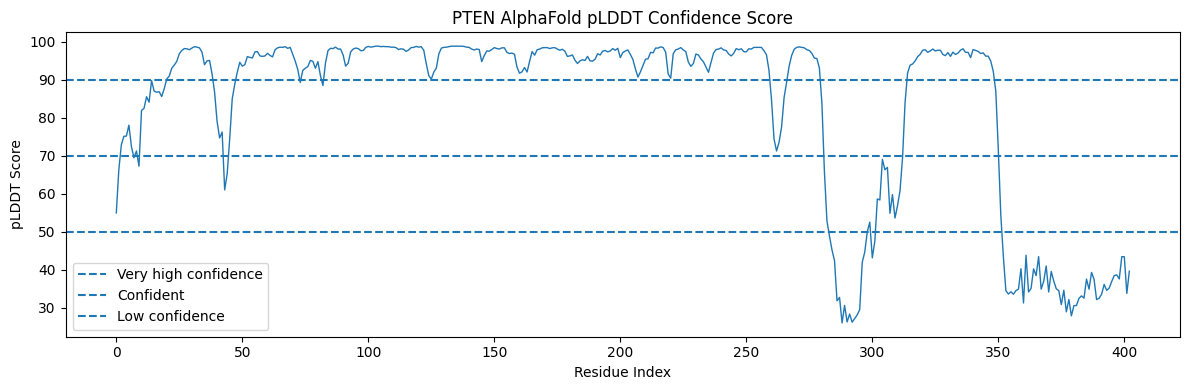

In [ ]:
#pLDDT CONFIDENCE PLOT
parser = PDBParser(QUIET=True)
structure = parser.get_structure("AF_PTEN", "PTEN_alphafold.pdb")

plddt = []

for model in structure:
    for chain in model:
        for residue in chain:
            if "CA" in residue:
                plddt.append(residue["CA"].get_bfactor())

plt.figure(figsize=(12,4))
plt.plot(plddt, linewidth=1)

plt.axhline(90, linestyle="--", label="Very high confidence")
plt.axhline(70, linestyle="--", label="Confident")
plt.axhline(50, linestyle="--", label="Low confidence")

plt.title("PTEN AlphaFold pLDDT Confidence Score")
plt.xlabel("Residue Index")
plt.ylabel("pLDDT Score")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Calculate pLDDT Statistics
average_plddt = sum(plddt) / len(plddt)

high_confidence = sum(1 for x in plddt if x > 90)
good_confidence = sum(1 for x in plddt if x > 70)
low_confidence = sum(1 for x in plddt if x < 50)

print("Structure Validation Summary")
print("----------------------------")
print("Number of residues:", len(plddt))
print("Average pLDDT:", round(average_plddt, 2))
print("Residues > 90:", high_confidence)
print("Residues > 70:", good_confidence)
print("Residues < 50:", low_confidence)

Structure Validation Summary
----------------------------
Number of residues: 403
Average pLDDT: 83.03
Residues > 90: 277
Residues > 70: 313
Residues < 50: 69


In [ ]:
#Download ligand
cid = "6442177"  # SF1670
sdf_file = "SF1670.sdf"

urls = [
    f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/SDF?record_type=3d",
    f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/SDF"
]

downloaded = False

for url in urls:
    print("Trying:", url)
    r = requests.get(url, timeout=30)

    if r.status_code == 200 and "M  END" in r.text:
        with open(sdf_file, "w") as f:
            f.write(r.text)

        print("Ligand downloaded successfully from:", url)
        downloaded = True
        break

if not downloaded:
    raise Exception("Ligand download failed")

Trying: https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/6442177/SDF?record_type=3d
Trying: https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/6442177/SDF
Ligand downloaded successfully from: https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/6442177/SDF


In [ ]:
#prepare ligand for docking
!obabel SF1670.sdf -O SF1670.pdb
!obabel SF1670.sdf -O SF1670.pdbqt

1 molecule converted
1 molecule converted


In [ ]:
#FIND DOCKING CENTER

pocket_residues = ["HIS", "CYS", "ARG", "LYS", "GLY"]

parser = PDBParser(QUIET=True)
structure = parser.get_structure("PTEN", "PTEN_cleanprotein.pdb")

coords = []

for model in structure:
    for chain in model:
        for residue in chain:
            if residue.get_resname() in pocket_residues:
                for atom in residue:
                    coords.append(atom.coord)

coords = np.array(coords)

center_x, center_y, center_z = coords.mean(axis=0)

print("NEW ACTIVE SITE CENTER:")
print(center_x, center_y, center_z)

NEW ACTIVE SITE CENTER:
35.06179 83.71493 30.46342


In [54]:
#RUN GNINA DOCKING
!./gnina \
-r PTEN_cleanprotein.pdb \
-l SF1670.pdbqt \
--center_x 35.06179 \
--center_y 83.71493 \
--center_z 30.46342 \
--size_x 28 \
--size_y 28 \
--size_z 28 \
--exhaustiveness 10 \
--num_modes 10 \
--seed 42 \
-o PTEN_SF1670_docked.sdf
#EXTRACT BEST POSE
!obabel PTEN_SF1670_docked.sdf -O PTEN_best_pose.pdb -f 1 -l 1
#SHOW RESULT SUMMARY
print("Docking completed successfully")
print("Best pose file created: PTEN_best_pose.pdb")


              _             
             (_)            
   __ _ _ __  _ _ __   __ _ 
  / _` | '_ \| | '_ \ / _` |
 | (_| | | | | | | | | (_| |
  \__, |_| |_|_|_| |_|\__,_|
   __/ |                    
  |___/                     

gnina v1.1 master:e4cb380+   Built Dec 18 2023.
gnina is based on smina and AutoDock Vina.
Please cite appropriately.

Recommend running with single model (--cnn crossdock_default2018)
or without cnn scoring (--cnn_scoring=none).

Commandline: ./gnina -r PTEN_cleanprotein.pdb -l SF1670.pdbqt --center_x 35.06179 --center_y 83.71493 --center_z 30.46342 --size_x 28 --size_y 28 --size_z 28 --exhaustiveness 10 --num_modes 10 --seed 42 -o PTEN_SF1670_docked.sdf
*** Open Babel Warning  in PerceiveBondOrders
  Failed to kekulize aromatic bonds in OBMol::PerceiveBondOrders

Using random seed: 42

0%   10   20   30   40   50   60   70   80   90   100%
|----|----|----|----|----|----|----|----|----|----|
***************************************************
 | pose 0 | i

In [55]:
#SCORE TABLE
scores = [-10.47, -8.12, -9.18, -9.94, -8.83,
          -8.61, -7.56, -8.36, -9.04, -7.98]

df = pd.DataFrame({
    "Pose": list(range(1, 11)),
    "Affinity (kcal/mol)": scores
})

df

,Pose,Affinity (kcal/mol)
0,1,-10.47
1,2,-8.12
2,3,-9.18
3,4,-9.94
4,5,-8.83
5,6,-8.61
6,7,-7.56
7,8,-8.36
8,9,-9.04
9,10,-7.98


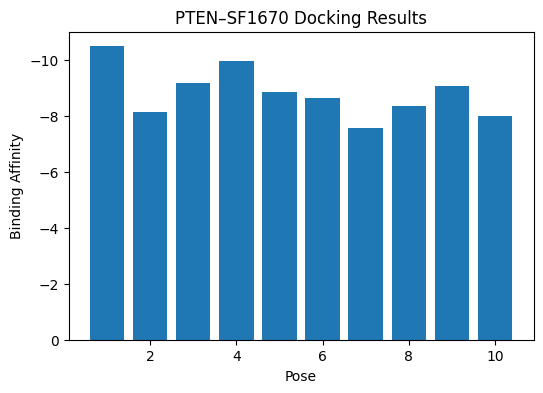

In [56]:
#plot docking results
plt.figure(figsize=(6,4))
plt.bar(df["Pose"], df["Affinity (kcal/mol)"])
plt.gca().invert_yaxis()
plt.xlabel("Pose")
plt.ylabel("Binding Affinity")
plt.title("PTEN–SF1670 Docking Results")
plt.show()

In [57]:
#visualization of the best docking result
display(HTML("<h3>PTEN–SF1670 Docked Complex</h3>"))

with open("PTEN_cleanprotein.pdb") as f:
    protein = f.read()

with open("PTEN_best_pose.pdb") as f:
    ligand = f.read()

view = py3Dmol.view(width=850, height=500)

view.addModel(protein, "pdb")
view.setStyle({"model": 0}, {"cartoon": {"color": "spectrum"}})

view.addModel(ligand, "pdb")
view.setStyle({"model": 1}, {"stick": {"colorscheme": "greenCarbon"}})

view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.